# Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

## 1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 118,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

## 2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. Specifically, we investigate:
- What is the primary driver of dropout: academic preparedness, current performance, or financial constraints?
- How do financial factors interact with academic factors to influence dropout risk?
- Does the impact vary significantly by demographics, programme of study, or engagement levels?
- Can a predictive model identify students at high risk of dropping out early?

## 3. Objectives
1. **Descriptive Analysis** — Profile the student population and compare characteristics of dropouts vs. persisters.
2. **Exploratory Analysis** — Investigate relationships between independent variables and dropout status.
3. **Predictive Modelling** — Develop and evaluate a stacking classifier to predict dropout risk.
4. **Actionable Insights** — Translate findings into recommendations for administrators and policymakers.

## 1. Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Statistics
from scipy.stats import chi2_contingency, ttest_ind

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

# Model selection
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV
)

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score
)

# Pipeline
from sklearn.pipeline import Pipeline

# Warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading

In [2]:
School_df = pd.read_csv("student.csv")
School_df.head()

,Gender,Birthdate,PHYSICALLYCHALLENGED,County,Loan_serial_number,ScholarshipApplied,InstitutionCode,InstitutionName,COURSECODE,ProgramCost,...,Category,applicanttype,LoanStatus,Unnamed: 21,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,0,MIGORI,2510374563,0,KPU,TECHNICAL UNIVERSITY OF KENYA,EEEI,270000.0,...,PublicUniversityGovtSponsored,1,Partially Disbursed,NaN,69,64,Primary,Primary,Primary,0
1,Male,08/07/1982,0,NaN,2510057518,0,CA,Catholic University,BED,160000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,63,65,Diploma,Secondary,Diploma,1
2,Male,18/02/1993,0,NaN,2510233585,0,MTK,Mount Kenya University,BBIT,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,57,Primary,Secondary,Secondary,0
3,Male,18/03/1986,0,NaN,2510031694,0,KAFUCO,Kaimosi Friends University,HNR,275400.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,51,76,Diploma,Primary,Diploma,0
4,Male,31/10/1987,0,NAKURU,2510438107,0,UBG,Bugema University,BHT,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,58,64,Secondary,Secondary,Secondary,0


In [3]:
print(School_df.shape)
School_df.info()

(118259, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                62659 non-null   object 
 1   Birthdate             118259 non-null  object 
 2   PHYSICALLYCHALLENGED  118259 non-null  int64  
 3   County                118235 non-null  object 
 4   Loan_serial_number    118259 non-null  int64  
 5   ScholarshipApplied    118259 non-null  int64  
 6   InstitutionCode       118259 non-null  object 
 7   InstitutionName       118259 non-null  object 
 8   COURSECODE            117794 non-null  object 
 9   ProgramCost           117794 non-null  float64
 10  CourseCategory        114059 non-null  object 
 11  Adm No                118233 non-null  object 
 12  ExamYear              118259 non-null  int64  
 13  INDEXNUMBER           118258 non-null  object 
 14  TotalLoanAllocated    118259 non-null  

In [4]:
School_df.isna().sum()

Gender                   55600
Birthdate                    0
PHYSICALLYCHALLENGED         0
County                      24
Loan_serial_number           0
ScholarshipApplied           0
InstitutionCode              0
InstitutionName              0
COURSECODE                 465
ProgramCost                465
CourseCategory            4200
Adm No                      26
ExamYear                     0
INDEXNUMBER                  1
TotalLoanAllocated           0
LoanproductCode              0
BursaryAllocated             0
BURSARYBATCHNUMBER      118259
Category                     0
applicanttype                0
LoanStatus                   3
Unnamed: 21             118259
Mother_Age                   0
Father_Age                   0
Father_educ_level        16817
Mother_educ_level        20568
Highest_educ_level       13548
Drop_out                     0
dtype: int64

## 3. Data Cleaning

### 3.1 Drop Irrelevant Columns

In [5]:
columns_to_drop = [
    'BURSARYBATCHNUMBER', 'Unnamed: 21', 'PHYSICALLYCHALLENGED',
    'Loan_serial_number', 'InstitutionCode', 'Adm No',
    'COURSECODE', 'INDEXNUMBER', 'BursaryAllocated', 'applicanttype'
]
School_df = School_df.drop(columns=columns_to_drop, errors='ignore')
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out'],
      dtype='object')

### 3.2 Drop Rows with Missing Values in Key Columns

In [6]:
School_df = School_df.dropna(subset=[
    "Gender", "County", "ProgramCost", "CourseCategory",
    "Father_educ_level", "Mother_educ_level", "LoanStatus", "Highest_educ_level"
])
School_df.isna().sum()

Gender                0
Birthdate             0
County                0
ScholarshipApplied    0
InstitutionName       0
ProgramCost           0
CourseCategory        0
ExamYear              0
TotalLoanAllocated    0
LoanproductCode       0
Category              0
LoanStatus            0
Mother_Age            0
Father_Age            0
Father_educ_level     0
Mother_educ_level     0
Highest_educ_level    0
Drop_out              0
dtype: int64

### 3.3 Remove Unsupported Loan Product Codes

In [7]:
School_df = School_df[
    ~School_df['LoanproductCode'].isin(['DL6', 'VC'])
]
School_df['LoanproductCode'].value_counts()

UG    47652
Name: LoanproductCode, dtype: int64

### 3.4 Remove Duplicates

In [8]:
print("Duplicates before:", School_df.duplicated().sum())
School_df = School_df.drop_duplicates()
print("Duplicates after:", School_df.duplicated().sum())

Duplicates before: 6
Duplicates after: 0


## 4. Feature Engineering

### Assumptions
- Age 16+ is eligible to join an undergraduate programme.

### 4.1 Create Age Column

In [9]:
# Convert Birthdate to datetime and derive age
School_df["Birthdate"] = pd.to_datetime(School_df["Birthdate"], errors="coerce")
today = datetime.today()
School_df["age"] = School_df["Birthdate"].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
    if pd.notnull(x) else None
)

### 4.2 Extract University Type and Sponsorship from Category

In [10]:
School_df[['UniversityType', 'Sponsored']] = School_df['Category'].str.extract(
    r'^(Public|Private).*?(GovtSponsored|SelfSponsored)$'
)
School_df[['UniversityType', 'Sponsored']].value_counts()

UniversityType  Sponsored    
Public          GovtSponsored    41972
Private         SelfSponsored     3699
Public          SelfSponsored     1132
Private         GovtSponsored      843
dtype: int64

### 4.3 Create Age Groups

In [11]:
bins   = [0, 18, 21, 25]
labels = ['<17', '18-21', '22-25']
School_df['age_group'] = pd.cut(School_df['age'], bins=bins, labels=labels)
School_df['age_group'].value_counts()

18-21    35003
<17       6549
22-25     5446
Name: age_group, dtype: int64

### 4.4 Export Cleaned Dataset

In [12]:
School_df.to_csv('cleaned.csv', index=False)
print(f"Cleaned dataset saved: {School_df.shape[0]} rows, {School_df.shape[1]} columns")

Cleaned dataset saved: 47646 rows, 22 columns


## 5. Exploratory Data Analysis

### 5.1 Age Distribution

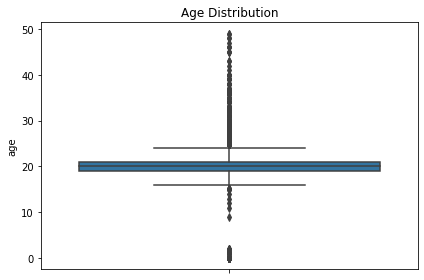

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=School_df['age'])
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

In [14]:
# Filter to valid student age range to deal with
School_df = School_df[School_df['age'] >= 17]
School_df = School_df[(School_df['age'] >= 16) & (School_df['age'] <= 25)]
School_df['age'].describe()

count    46882.000000
mean        19.805597
std          1.394240
min         17.000000
25%         19.000000
50%         20.000000
75%         21.000000
max         25.000000
Name: age, dtype: float64

In [15]:
School_df.age.value_counts()

19.0    16183
20.0    12331
21.0     6489
18.0     5702
22.0     3226
23.0     1408
17.0      731
24.0      559
25.0      253
Name: age, dtype: int64

### 5.2 School Drop Out Rate by County in Kenya

In [16]:
# 1. Standardize to uppercase and strip whitespace
School_df['County'] = School_df['County'].astype(str).str.upper().str.strip()

# 2. Cleanup punctuation and spacing
# We replace slashes and hyphens with spaces, but we'll handle the apostrophe carefully
School_df['County'] = School_df['County'].str.replace(r'[-/]', ' ', regex=True)
School_df['County'] = School_df['County'].str.replace(r'\s+', ' ', regex=True)

# 3. Specific fix for Murang'a and other duplicates
mapping = {
    'MURANG A': "MURANG'A",
    'MURANGA': "MURANG'A",
    'TRANSNZOIA': 'TRANS NZOIA'
}

School_df['County'] = School_df['County'].replace(mapping)

# 4. Verification
unique_counties = sorted(School_df['County'].unique())
print(f"Unique County Count: {len(unique_counties)}")
print(unique_counties)

Unique County Count: 47
['BARINGO', 'BOMET', 'BUNGOMA', 'BUSIA', 'ELGEYO MARAKWET', 'EMBU', 'GARISSA', 'HOMA BAY', 'ISIOLO', 'KAJIADO', 'KAKAMEGA', 'KERICHO', 'KIAMBU', 'KILIFI', 'KIRINYAGA', 'KISII', 'KISUMU', 'KITUI', 'KWALE', 'LAIKIPIA', 'LAMU', 'MACHAKOS', 'MAKUENI', 'MANDERA', 'MARSABIT', 'MERU', 'MIGORI', 'MOMBASA', "MURANG'A", 'NAIROBI', 'NAKURU', 'NANDI', 'NAROK', 'NYAMIRA', 'NYANDARUA', 'NYERI', 'SAMBURU', 'SIAYA', 'TAITA TAVETA', 'TANA RIVER', 'THARAKA NITHI', 'TRANS NZOIA', 'TURKANA', 'UASIN GISHU', 'VIHIGA', 'WAJIR', 'WEST POKOT']


In [17]:
School_df.County.unique()

array(['KAKAMEGA', 'KAJIADO', 'KISUMU', 'NYAMIRA', 'NAIROBI', 'KIAMBU',
       'KITUI', 'MACHAKOS', 'UASIN GISHU', 'MOMBASA', 'MIGORI',
       'ELGEYO MARAKWET', 'BUNGOMA', 'KILIFI', 'BOMET', 'TRANS NZOIA',
       'HOMA BAY', 'MERU', 'THARAKA NITHI', 'KWALE', "MURANG'A", 'NYERI',
       'BUSIA', 'NAKURU', 'KISII', 'KIRINYAGA', 'NANDI', 'VIHIGA',
       'SIAYA', 'MAKUENI', 'NYANDARUA', 'TAITA TAVETA', 'LAIKIPIA',
       'KERICHO', 'LAMU', 'NAROK', 'SAMBURU', 'BARINGO', 'EMBU',
       'WEST POKOT', 'GARISSA', 'MARSABIT', 'TURKANA', 'TANA RIVER',
       'ISIOLO', 'MANDERA', 'WAJIR'], dtype=object)

In [18]:
# Create the summary table
dropout_table = School_df.groupby('County').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_table['Dropout_Percentage'] = (
    dropout_table['Dropout_Count'] / dropout_table['Total_Students'] * 100
).round(2)

# Sort by highest dropout percentage
dropout_table = dropout_table.sort_values('Dropout_Percentage', ascending=False)

# Reset index cleanly
dropout_table = dropout_table.reset_index(drop=True)

print(dropout_table)

             County  Total_Students  Dropout_Count  Dropout_Percentage
0           MANDERA              21              9               42.86
1             WAJIR              28             11               39.29
2          MARSABIT              90             34               37.78
3              LAMU              60             22               36.67
4           SAMBURU              73             25               34.25
5         KIRINYAGA             373            125               33.51
6              EMBU             447            149               33.33
7            KISUMU            1860            594               31.94
8       TRANS NZOIA            1238            395               31.91
9           NYAMIRA            1727            546               31.62
10            BOMET            1390            437               31.44
11          BUNGOMA            2075            642               30.94
12            BUSIA            1293            400               30.94
13    

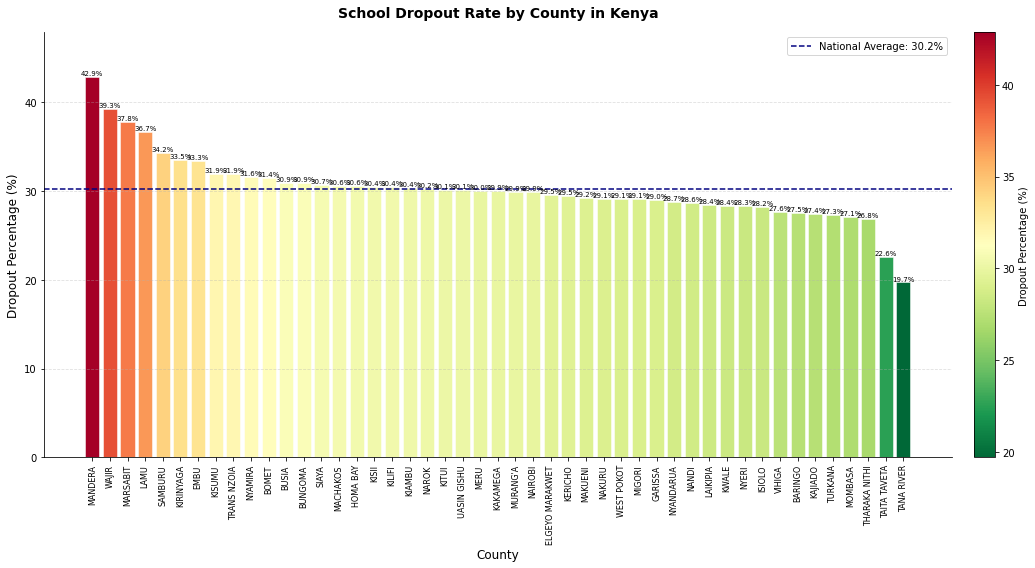

In [19]:
# Sort by percentage highest to lowest
dropout_plot = dropout_table.sort_values('Dropout_Percentage', ascending=False).reset_index(drop=True)

# Create colour gradient — green (low) to red (high)
norm = plt.Normalize(
    dropout_plot['Dropout_Percentage'].min(),
    dropout_plot['Dropout_Percentage'].max()
)
colors = cm.RdYlGn_r(norm(dropout_plot['Dropout_Percentage']))

# Create the figure
fig, ax = plt.subplots(figsize=(16, 8))

# Plot vertical bar chart with gradient colours
bars = ax.bar(
    dropout_plot['County'],
    dropout_plot['Dropout_Percentage'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add percentage labels on top of each bar
for bar, val in zip(bars, dropout_plot['Dropout_Percentage']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center',
        fontsize=7
    )

# Add colourbar legend
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Dropout Percentage (%)', fontsize=10)

# Formatting
ax.set_ylabel('Dropout Percentage (%)', fontsize=12)
ax.set_xlabel('County', fontsize=12)
ax.set_title('School Dropout Rate by County in Kenya', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, dropout_plot['Dropout_Percentage'].max() + 5)
ax.axhline(
    dropout_table['Dropout_Percentage'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f"National Average: {dropout_table['Dropout_Percentage'].mean():.1f}%"
)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
#Create the summary table by ExamYear
dropout_year_table = School_df.groupby('ExamYear').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_year_table['Dropout_Percentage'] = (
    dropout_year_table['Dropout_Count'] / dropout_year_table['Total_Students'] * 100
).round(2)

# Sort by ExamYear
dropout_year_table = dropout_year_table.sort_values('ExamYear', ascending=True).reset_index(drop=True)

print(dropout_year_table)

   ExamYear  Total_Students  Dropout_Count  Dropout_Percentage
0      2016               1              0                0.00
1      2017              19              7               36.84
2      2018              50             14               28.00
3      2019             142             37               26.06
4      2020             358            116               32.40
5      2021            1097            321               29.26
6      2022             680            198               29.12
7      2023            2272            662               29.14
8      2024           42263          12742               30.15


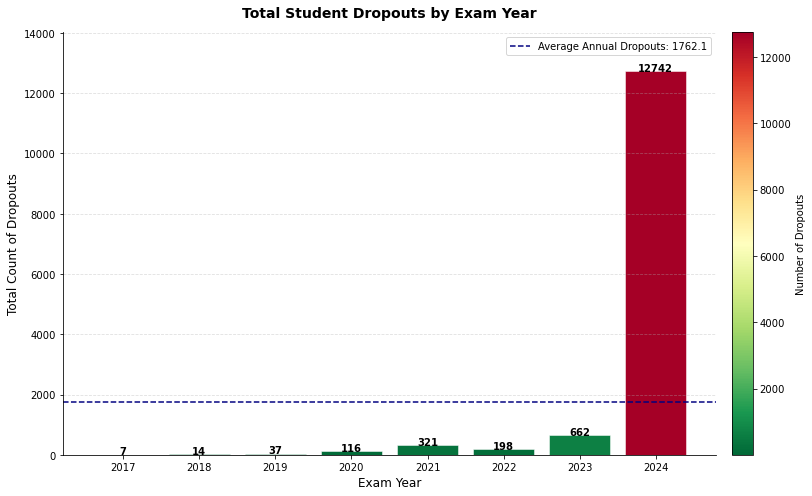

In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Prepare the data: Count the number of dropouts per year
# We filter the dataframe for only dropouts and then group by year
dropout_counts = School_df[School_df['Drop_out'] == 1].groupby('ExamYear').size().reset_index(name='Dropout_Count')

# 2. Plotting logic
fig, ax = plt.subplots(figsize=(12, 7))

# Normalization for the color map based on counts
norm = plt.Normalize(
    dropout_counts['Dropout_Count'].min(),
    dropout_counts['Dropout_Count'].max()
)
colors = cm.RdYlGn_r(norm(dropout_counts['Dropout_Count']))

bars = ax.bar(
    dropout_counts['ExamYear'].astype(str),
    dropout_counts['Dropout_Count'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add count labels on top of each bar
for bar, val in zip(bars, dropout_counts['Dropout_Count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{int(val)}',  # Displaying as integer count
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Colourbar updated for counts
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Number of Dropouts', fontsize=10)

# Labels and Title
ax.set_ylabel('Total Count of Dropouts', fontsize=12)
ax.set_xlabel('Exam Year', fontsize=12)
ax.set_title('Total Student Dropouts by Exam Year', fontsize=14, fontweight='bold', pad=15)

# Update Y-limit to provide space for labels
ax.set_ylim(0, dropout_counts['Dropout_Count'].max() * 1.1)

# Horizontal line for the average annual count
avg_count = dropout_counts['Dropout_Count'].mean()
ax.axhline(
    avg_count,
    color='navy', linestyle='--', linewidth=1.5,
    label=f"Average Annual Dropouts: {avg_count:.1f}"
)

ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
School_df.shape

(46882, 22)

In [23]:
# 1. (Optional but recommended) Ensure ExamYear is numeric to avoid type errors
School_df['ExamYear'] = pd.to_numeric(School_df['ExamYear'], errors='coerce')

# 2. Filter for the year 2024
School_df = School_df[School_df['ExamYear'] == 2024]

# 3. Check the results
print(f"Rows after filtering: {len(School_df)}")
print(f"Unique years in data: {School_df['ExamYear'].unique()}")

Rows after filtering: 42263
Unique years in data: [2024]


### 5.3 Age Group vs Dropout

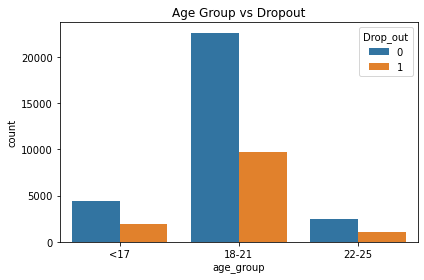

In [24]:
sns.countplot(x='age_group', hue='Drop_out', data=School_df)
plt.title('Age Group vs Dropout')
plt.tight_layout()
plt.show()

### 5.4 Loan-to-Cost Ratio by University Type

# Remove Outliers

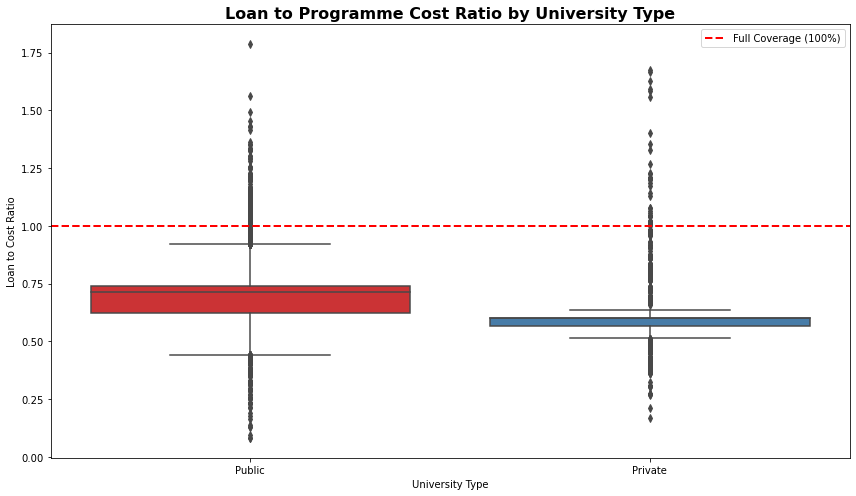

In [26]:
df_ratio = School_df.dropna(subset=['ProgramCost', 'TotalLoanAllocated']).copy()
df_ratio = df_ratio[df_ratio['ProgramCost'] > 0]
df_ratio['LoanToCostRatio'] = (df_ratio['TotalLoanAllocated'] / df_ratio['ProgramCost']).clip(upper=2)

plt.figure(figsize=(12, 7))
sns.boxplot(x='UniversityType', y='LoanToCostRatio', data=df_ratio, palette='Set1')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Full Coverage (100%)')
plt.title('Loan to Programme Cost Ratio by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Loan to Cost Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
School_df.columns

**Interpretation:** Public universities show a higher loan-to-cost ratio due to government support and lower fees.
Private universities have a lower ratio, reflecting higher programme costs relative to loan allocations.

# EDIT ME

### 5.6 Dropout Rate by Age Group

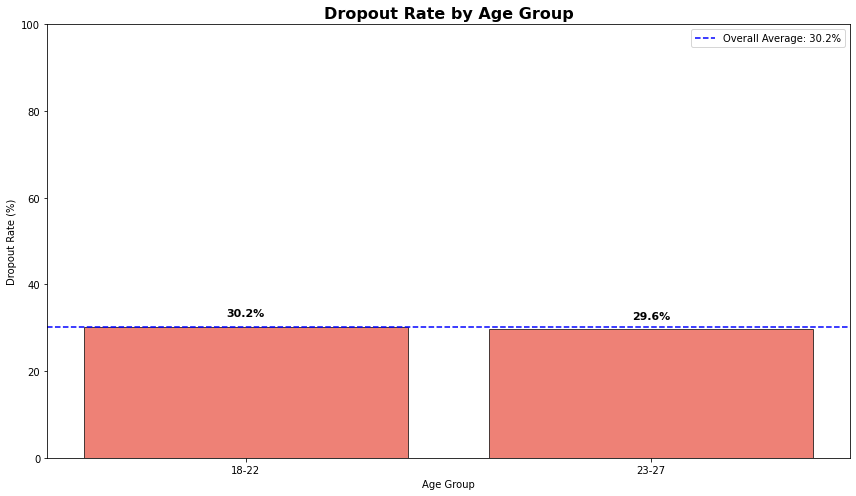

In [27]:
df_age_group = School_df.dropna(subset=['age']).copy()
df_age_group = df_age_group[(df_age_group['age'] >= 18) & (df_age_group['age'] <= 60)]
bins2   = [18, 22, 27, 32, 40, 100]
labels2 = ['18-22', '23-27', '28-32', '33-40', '40+']
df_age_group['AgeGroup'] = pd.cut(df_age_group['age'], bins=bins2, labels=labels2, right=False)
dropout_by_age = df_age_group.groupby('AgeGroup')['Drop_out'].agg(['mean', 'count'])
dropout_by_age = dropout_by_age[dropout_by_age['count'] > 10]

plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(dropout_by_age)), dropout_by_age['mean'] * 100,
               color='#e74c3c', edgecolor='black', alpha=0.7)
plt.xticks(range(len(dropout_by_age)), dropout_by_age.index)
plt.title('Dropout Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)
for bar, rate in zip(bars, dropout_by_age['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
overall = df_age_group['Drop_out'].mean() * 100
plt.axhline(y=overall, color='blue', linestyle='--', label=f'Overall Average: {overall:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

### 5.7 Scholarship Application & Loan Amount

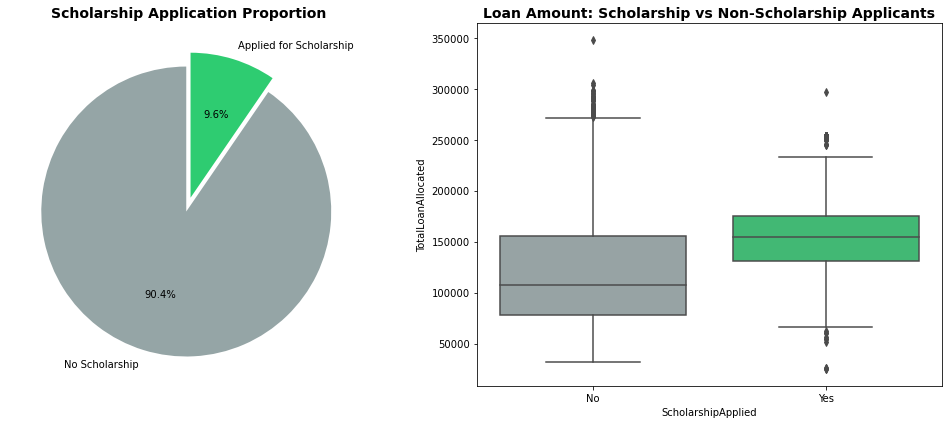

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scholarship_counts = School_df['ScholarshipApplied'].value_counts()
axes[0].pie(scholarship_counts.values,
            labels=['No Scholarship', 'Applied for Scholarship'],
            autopct='%1.1f%%', colors=['#95a5a6', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Scholarship Application Proportion', fontsize=14, fontweight='bold')

sns.boxplot(x='ScholarshipApplied', y='TotalLoanAllocated', data=School_df,
            ax=axes[1], palette=['#95a5a6', '#2ecc71'])
axes[1].set_title('Loan Amount: Scholarship vs Non-Scholarship Applicants', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

### 5.8 Loan Distribution by Demographic Groups

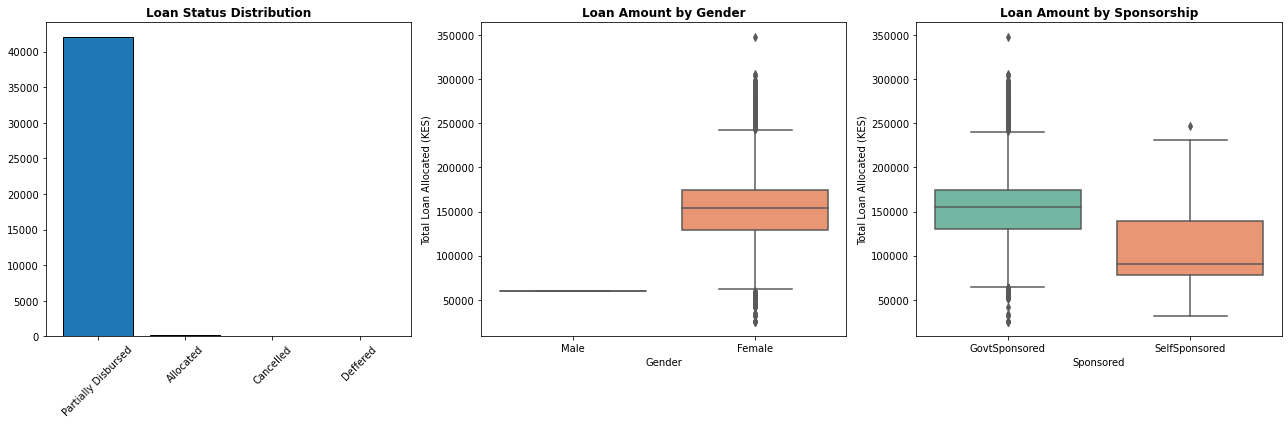

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes,
                           ['LoanStatus', 'Gender', 'Sponsored'],
                           ['Loan Status Distribution', 'Loan Amount by Gender', 'Loan Amount by Sponsorship']):
    if col == 'LoanStatus':
        counts = School_df[col].value_counts()
        ax.bar(counts.index, counts.values, edgecolor='black')
        ax.set_title(title, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
    else:
        sns.boxplot(x=col, y='TotalLoanAllocated', data=School_df, ax=ax, palette='Set2')
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Total Loan Allocated (KES)')

plt.tight_layout()
plt.show()

### 5.11 Dropout Status by University Type

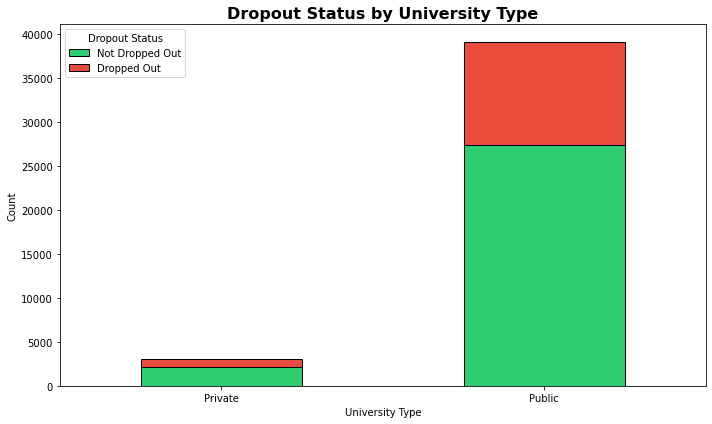

In [32]:
dropout_by_type = pd.crosstab(School_df['UniversityType'], School_df['Drop_out'])
dropout_by_type.columns = ['Not Dropped Out', 'Dropped Out']
dropout_by_type.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black', figsize=(10, 6))
plt.title('Dropout Status by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Dropout Status')
plt.tight_layout()
plt.show()

In [33]:
# Filter the dataframe to exclude 'Private'
School_df = School_df[School_df['UniversityType'] != 'Private']

# Optional: Reset the index after dropping rows
School_df = School_df.reset_index(drop=True)

# Verification
print(f"Remaining rows: {len(School_df)}")
print(f"University types currently in data: {School_df['UniversityType'].unique()}")

Remaining rows: 39173
University types currently in data: ['Public']


### 5.12 Average Loan by Parental Education Level

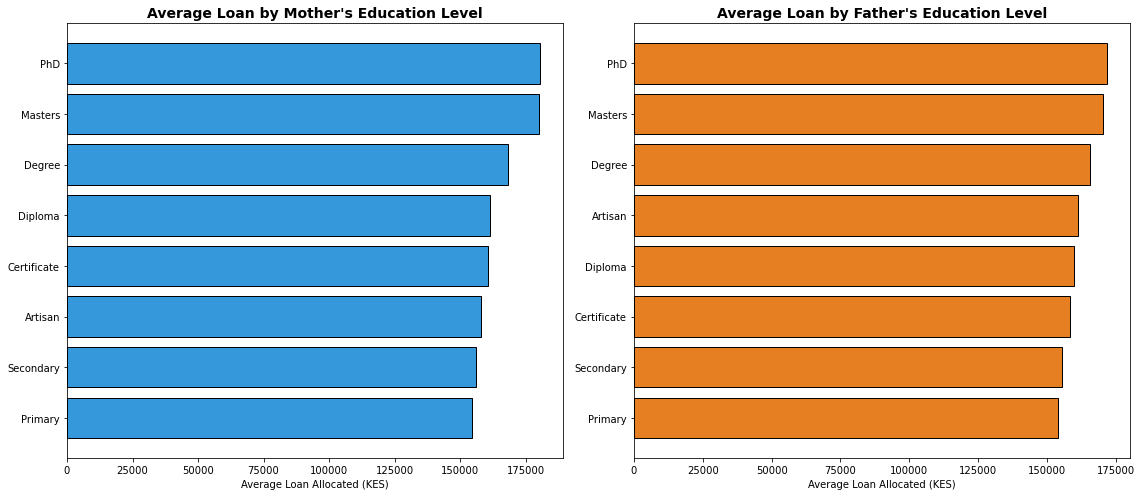

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, color, title in zip(
    axes,
    ['Mother_educ_level', 'Father_educ_level'],
    ['#3498db', '#e67e22'],
    ["Average Loan by Mother's Education Level", "Average Loan by Father's Education Level"]
):
    edu = School_df.groupby(col)['TotalLoanAllocated'].mean().sort_values()
    ax.barh(edu.index, edu.values, color=color, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Loan Allocated (KES)')
plt.tight_layout()
plt.show()

## 6. Hypothesis Tests

### 6.1 Scholarship Application vs Dropout
- **H₀:** No significant association between scholarship application and dropout status.
- **H₁:** Scholarship application is significantly associated with dropout status.

In [35]:
table = pd.crosstab(School_df['ScholarshipApplied'], School_df['Drop_out'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print("Decision:", "Reject H₀" if p < 0.05 else "Fail to reject H₀")

Chi-square statistic: 0.0567
p-value: 0.8117
Decision: Fail to reject H₀


### 6.2 Loan Amount vs Dropout
- **H₀:** Loan amount has no effect on dropout status.
- **H₁:** Loan amount is significantly associated with dropout status.

T-statistic: -1.4573
P-value: 0.1451
Decision: Fail to reject H₀


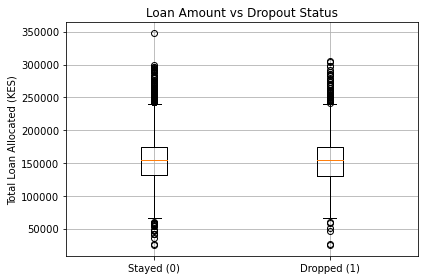

In [36]:
dropped = School_df[School_df['Drop_out'] == 1]['TotalLoanAllocated'].dropna()
stayed  = School_df[School_df['Drop_out'] == 0]['TotalLoanAllocated'].dropna()
t_stat, p_value = ttest_ind(dropped, stayed, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print("Decision:", "Reject H₀" if p_value < 0.05 else "Fail to reject H₀")

plt.figure(figsize=(6, 4))
plt.boxplot([stayed, dropped], labels=['Stayed (0)', 'Dropped (1)'])
plt.title('Loan Amount vs Dropout Status')
plt.ylabel('Total Loan Allocated (KES)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.3 Parental Education Levels vs Dropout
Testing father's, mother's, and highest parental education level against dropout status.

In [37]:
for col, label in [
    ('Father_educ_level', "Father's Education"),
    ('Mother_educ_level', "Mother's Education"),
    ('Highest_educ_level', 'Highest Parental Education')
]:
    table = pd.crosstab(School_df[col], School_df['Drop_out'])
    chi2, p, dof, _ = chi2_contingency(table)
    decision = "Reject H₀" if p < 0.05 else "Fail to reject H₀"
    print(f"{label:<35} | chi2={chi2:.4f} | p={p:.4f} | {decision}")

Father's Education                  | chi2=8.2842 | p=0.3082 | Fail to reject H₀
Mother's Education                  | chi2=2.8906 | p=0.8949 | Fail to reject H₀
Highest Parental Education          | chi2=5.1357 | p=0.6434 | Fail to reject H₀


## 7. Modelling

### 7.1 Prepare Features and Target

In [41]:
# Define features and target
X = School_df.drop(columns=[
    'Drop_out', 'Birthdate', 'InstitutionName',
    'LoanproductCode', 'Mother_Age', 'Father_Age',
    'Father_educ_level', 'Mother_educ_level', 'age_group', 'ExamYear',
    'UniversityType'
], errors='ignore')

y = School_df['Drop_out']

print("Class distribution:")
print(y.value_counts())
print(f"\nDropout rate: {y.mean():.2%}")

Class distribution:
0    27369
1    11804
Name: Drop_out, dtype: int64

Dropout rate: 30.13%


In [42]:
X.columns

Index(['Gender', 'County', 'ScholarshipApplied', 'ProgramCost',
       'CourseCategory', 'TotalLoanAllocated', 'Category', 'LoanStatus',
       'Highest_educ_level', 'age', 'Sponsored'],
      dtype='object')

### 7.2 Encode and Split

**Fix applied:** `pd.get_dummies` is called on the full feature matrix **before** the train/test split.
This ensures both sets share identical columns, eliminating the leaky `align(join='left')` pattern.

In [43]:
# Encode categoricals BEFORE splitting to ensure consistent columns
X_encoded = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, train_size=0.8, random_state=452, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (31338, 82), Test: (7835, 82)


### 7.3 Define Models



In [ ]:
# Logistic Regression pipeline 
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5))
])

# Balanced Random Forest handles class imbalance via internal undersampling
rfc = BalancedRandomForestClassifier(random_state=254)

# XGBoost as final estimator — no scale_pos_weight needed; BRFC already balances
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

### 7.4 Build Stacking Classifier

In [ ]:
stack = StackingClassifier(
    estimators=[
        ('rfc', rfc),
        ('lr', lr_pipeline)   
    ],
    final_estimator=xgb,      
    stack_method='predict_proba',
    cv=5,                     
    n_jobs=-1
)

### 7.5 Train and Evaluate (Default Threshold = 0.5)

In [ ]:
stack.fit(X_train, y_train)
probs = stack.predict_proba(X_test)[:, 1]

preds = (probs > 0.5).astype(int)
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

### 7.6 Tune Decision Threshold on a Validation Split

In [ ]:
# Split training data into train / validation for threshold tuning
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Retrain on reduced training set to get validation probabilities
stack.fit(X_tr, y_tr)
val_probs = stack.predict_proba(X_val)[:, 1]

# Find threshold that maximises F1 on validation set
best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.01):
    temp_preds = (val_probs > t).astype(int)
    score = f1_score(y_val, temp_preds)
    if score > best_f1:
        best_f1, best_t = score, t

print(f"Best threshold (from validation set): {best_t:.2f}")
print(f"Best F1 on validation set: {best_f1:.4f}")

### 7.7 Final Evaluation on Test Set (Using Best Threshold)

In [ ]:
# Retrain on full training set, apply best threshold to untouched test set
stack.fit(X_train, y_train)
test_probs = stack.predict_proba(X_test)[:, 1]
final_preds = (test_probs > best_t).astype(int)

print(f"Evaluation with threshold = {best_t:.2f}\n")
print(classification_report(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, test_probs).round(4))

cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix (threshold = {best_t:.2f})")
plt.tight_layout()
plt.show()

### 7.8 Hyperparameter Tuning (Balanced Random Forest)

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 0.5]
}

random_search = RandomizedSearchCV(
    estimator=BalancedRandomForestClassifier(random_state=254),
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV F1 score:", round(random_search.best_score_, 4))

### 7.9 Evaluate Tuned Stack with Best RFC Params

In [ ]:
tuned_rfc = random_search.best_estimator_

stack_tuned = StackingClassifier(
    estimators=[
        ('rfc', tuned_rfc),
        ('lr', lr_pipeline)
    ],
    final_estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

stack_tuned.fit(X_train, y_train)
tuned_probs = stack_tuned.predict_proba(X_test)[:, 1]
tuned_preds = (tuned_probs > best_t).astype(int)

print(f"Tuned Stack — threshold = {best_t:.2f}\n")
print(classification_report(y_test, tuned_preds))
print("ROC-AUC:", roc_auc_score(y_test, tuned_probs).round(4))

cm_tuned = confusion_matrix(y_test, tuned_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_tuned).plot()
plt.title("Tuned Stack — Confusion Matrix")
plt.tight_layout()
plt.show()